### Setup

```
assignment_2/
├── data/
├── models/
|   ├── custom_random_forest.py
|   └── custom_regression_tree.py
└── notebooks/
    └── performance_comparison.ipynb
```

#### Dataset 1

1. Download the [Rice Paddy Yield](https://www.kaggle.com/datasets/kienngx/record-of-paddy-rice-crop-cultivation) dataset from Kaggle.
2. Unzip and save data as `Rice_Paddy_Yield.csv` into `data/`.

#### Dataset 2

1. Download the [Utrecht Housing](https://www.kaggle.com/datasets/ictinstitute/utrecht-housing-dataset) dataset from Kaggle.
2. Unzip and save `utrechthousingsmall.csv` as `Utrecht_Housing.csv` into `data/`.

#### Dataset 3

1. Download the [Student Performance](https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression) data from Kaggle.
2. Unzip and save data as `Student_Performance.csv` into `data/`.

#### Code Execution

To run the code for a specific dataset (_1_, _2_, or _3_):
1. Set the variable `SELECT_DATASET` to the number of the chosen dataset (i.e. `SELECT_DATASET = 3`).
2. Run the code.

### Required Modules

In [1]:
import os
import sys
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor

Load custom tree and random forest scripts:

In [2]:
project_root = os.path.abspath("..")
sys.path.append(project_root)

from models.custom_regression_tree import CustomRegressionTree as CRTree
from models.custom_random_forest import CustomRandomForest as CRForest

### Global Variables

Select dataset to run:

In [ ]:
SEED = 42
SELECT_DATASET = 1  # Change THIS variable to select dataset

# Dataset 1
# Rice paddy yield
if SELECT_DATASET == 1:
    DATASET = "Rice_Paddy_Yield"
    FILEPATH = os.path.join("..", "data", f"{DATASET}.csv")
    LABEL = "Paddy yield(in Kg)"
    PLOT_COLOR = "#990000ff"
    LABEL_RANGE = (4900, 40100)
    COLUMNS_TO_REMOVE = ["Trash(in bundles)"]
    COLUMNS_TO_DUMMY = []
    MAX_DEPTH = [4, 8, 16]
    MIN_SAMPLES_SPLIT = [2, 4, 8]
    N_TREES = [50]
    MAX_FEATURES = [5]
    ALPHA = [0.1, 1.0, 10.0, 100.0]
    MAX_ITER = [20000]

# Dataset 2
# Utrecht housing
elif SELECT_DATASET == 2:
    DATASET = "Utrecht_Housing"
    FILEPATH = os.path.join("..", "data", f"{DATASET}.csv")
    LABEL = "retailvalue"
    PLOT_COLOR = "#38761dff"
    LABEL_RANGE = (400000, 1400000)
    COLUMNS_TO_REMOVE = ["id", "taxvalue"]
    COLUMNS_TO_DUMMY = ["zipcode"]
    MAX_DEPTH = [4, 8, 16]
    MIN_SAMPLES_SPLIT = [2, 4, 8]
    N_TREES = [50]
    MAX_FEATURES = [13]
    ALPHA = [100.0, 1000.0, 10000.0, 100000.0]
    MAX_ITER = [10000]


# Dataset 3
# Student performance
else:
    DATASET = "Student_Performance"
    FILEPATH = os.path.join("..", "data", f"{DATASET}.csv")
    LABEL = "Performance Index"
    PLOT_COLOR = "#0b5394ff"
    LABEL_RANGE = (0, 102)
    COLUMNS_TO_REMOVE = []
    COLUMNS_TO_DUMMY = []
    MAX_DEPTH = [6, 12, 24]
    MIN_SAMPLES_SPLIT = [4, 8, 16]
    N_TREES = [50]
    MAX_FEATURES = [5]
    ALPHA = [0.01, 0.1, 1.0, 10.0]
    MAX_ITER = [10000]

### Utility Methods

In [4]:
def model_version(name: str, params: dict) -> str:
    """Join model name with parameters"""
    parameters = str(params).replace(":", "=").replace(" ", "").replace("'", "")
    return name + '@' + parameters


def get_scores(label: np.array, prediction: np.array) -> dict:
    """Calculate model prediction scores"""
    rmse = np.sqrt(np.mean((prediction - label) ** 2))
    mape = np.mean(np.abs((label - prediction) / label)) * 100
    return {"RMSE": rmse, "MAPE": mape}


def get_parameters(s: str) -> dict:
    """Retrieves model parameters from string"""
    pattern = r'(\w+)=([^,]+)'
    parameters = dict(re.findall(pattern, s.strip("{}")))
    for k, v in parameters.items():
        if v.isdigit():
            parameters[k] = int(v)
        else:
            parameters[k] = float(v)
    return parameters

### Data Ingestion

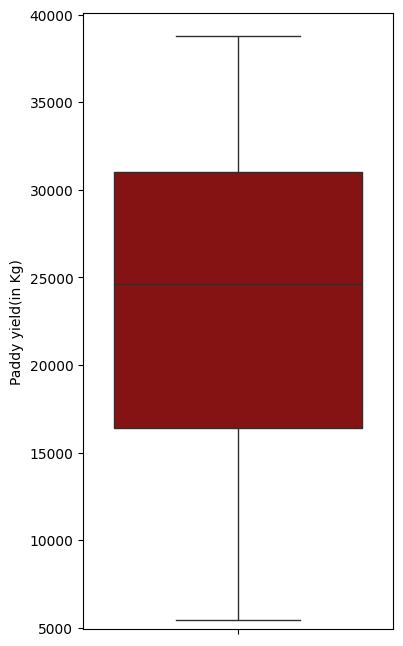

In [5]:
data = pd.read_csv(FILEPATH)
data = data.drop(columns=COLUMNS_TO_REMOVE, axis=1)
for column in COLUMNS_TO_DUMMY:
    data = pd.get_dummies(data, columns=[column], prefix = 'zip')

plt.figure(figsize=(4, 8))
sns.boxplot(data[LABEL], color=PLOT_COLOR)
plt.ylim(LABEL_RANGE)
plt.show()

## Modeling

Train and test (holdout) split:

In [6]:
df_trn, df_tst = train_test_split(
    data,
    train_size=0.7,
    shuffle=True,
    random_state=SEED)

df_trn.shape, df_tst.shape

((1952, 44), (837, 44))

### Define Hyperparameters

In [7]:
tree_param_grid = [
    {
        "max_depth": mxd,
        "min_samples_split": mss,
        "random_state": SEED }
    for mxd in MAX_DEPTH
    for mss in MIN_SAMPLES_SPLIT]

forest_param_grid = [
    {
        "n_estimators": ntr,
        "max_depth": mxd,
        "min_samples_split": mss,
        "max_features": mxf,
        "random_state": SEED }
    for ntr in N_TREES
    for mxd in MAX_DEPTH
    for mss in MIN_SAMPLES_SPLIT
    for mxf in MAX_FEATURES ]

linear_param_grid = [
    {
        "alpha": alp,
        "max_iter": mxi,
        "random_state": SEED}
    for alp in ALPHA
    for mxi in MAX_ITER ]


models_to_run = {
    "CustomRegressionTree": (CRTree, tree_param_grid),
    "SklearnRegressionTree": (DecisionTreeRegressor, tree_param_grid),
    "CustomRandomForest": (CRForest, forest_param_grid),
    "SklearnRandomForest": (RandomForestRegressor, forest_param_grid),
    "LassoRegression": (Lasso, linear_param_grid) }

### Cross-Validation

In [8]:
kf = KFold(n_splits=10, shuffle=True, random_state=SEED)

features = [c for c in df_trn if c != LABEL]
numeric_features = df_trn[features].select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in features if c not in numeric_features]

model_scores = {}
for indexes_trn, indexes_vln in kf.split(df_trn):

    X_trn_raw = df_trn.iloc[indexes_trn][features]
    X_vln_raw = df_trn.iloc[indexes_vln][features]

    y = df_trn[LABEL].values
    y_trn, y_vln = y[indexes_trn], y[indexes_vln]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_features),
            (
                "num",
                StandardScaler(),
                numeric_features)])

    X_trn = preprocessor.fit_transform(X_trn_raw)
    X_vln = preprocessor.transform(X_vln_raw)


    for name in models_to_run:
        regressor, parameter_grid = models_to_run[name]
        for params in parameter_grid:

            version = model_version(name, params)
            if version not in model_scores.keys():
                model_scores[version] = {"RMSE": [], "MAPE": []}

            model = regressor(**params)
            model.fit(X_trn, y_trn)
            prediction = model.predict(X_vln)

            metrics = get_scores(y_vln, prediction)
            model_scores[version]["RMSE"].append(metrics["RMSE"])
            model_scores[version]["MAPE"].append(metrics["MAPE"])

### Generate Plots

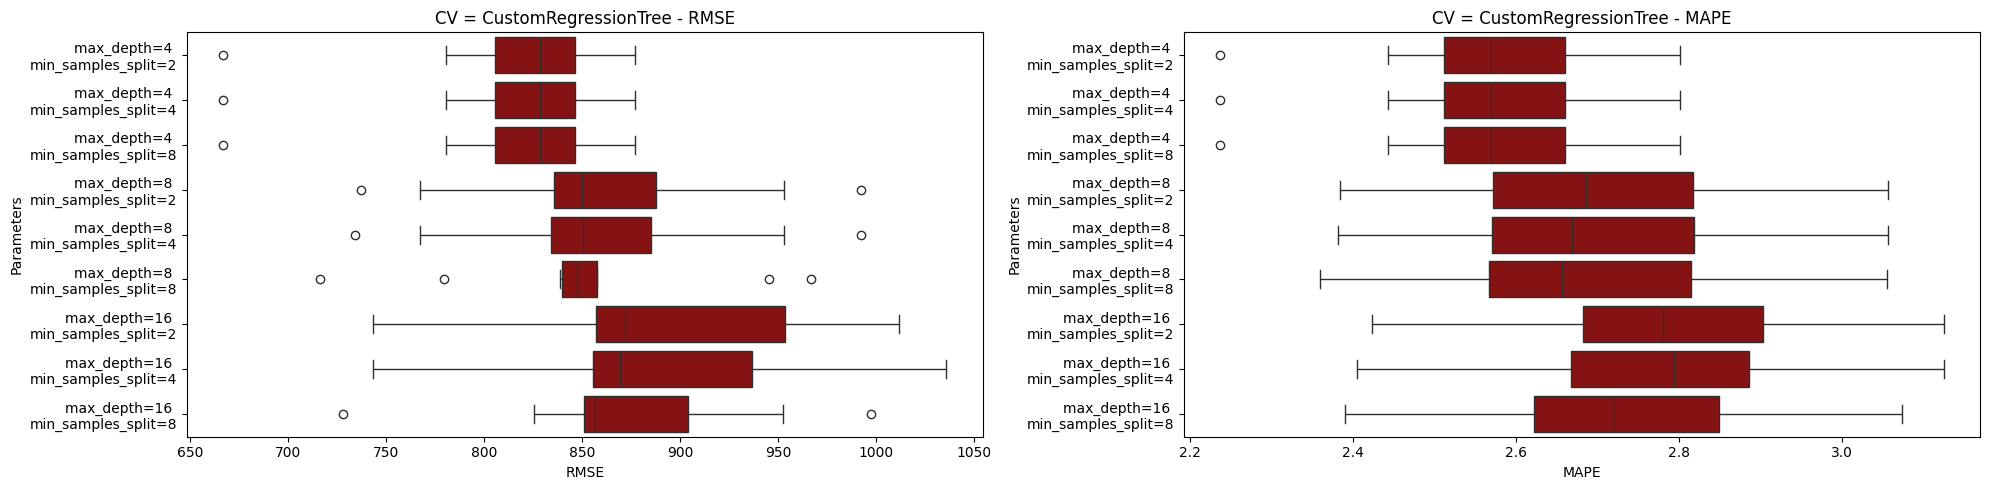

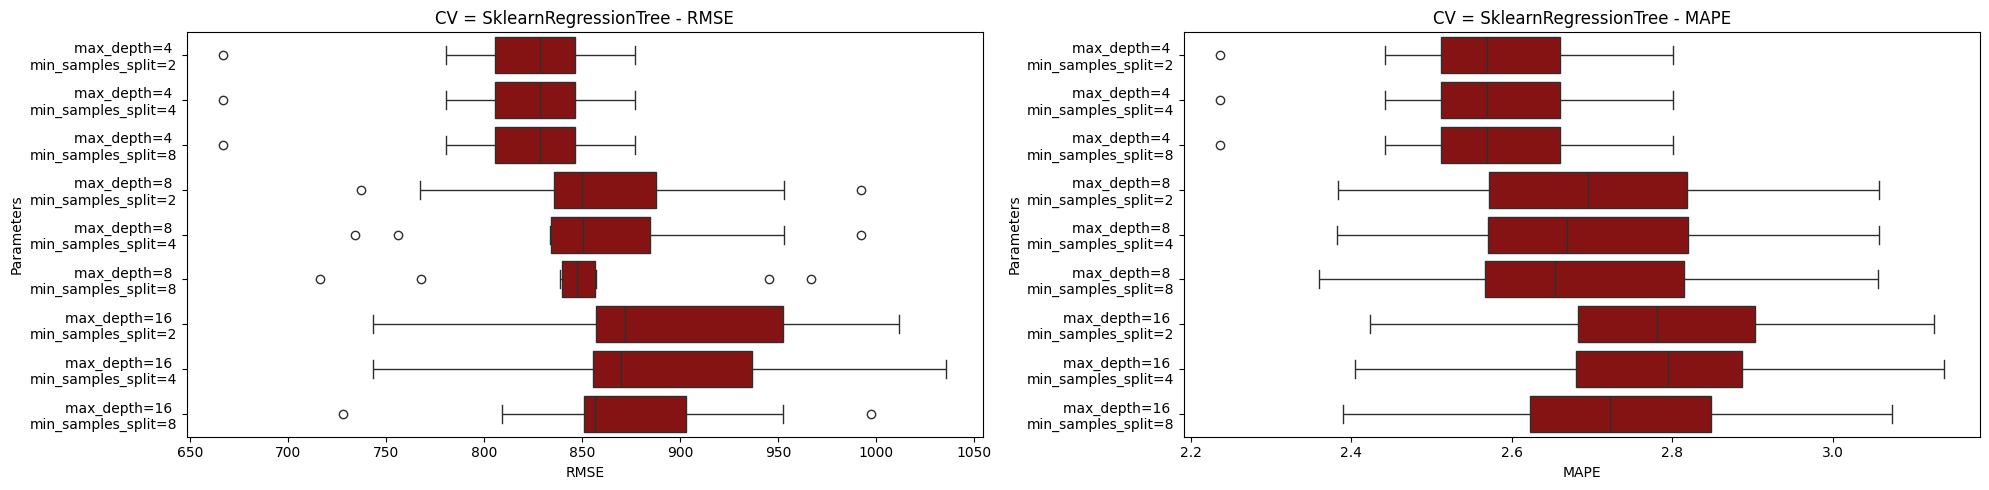

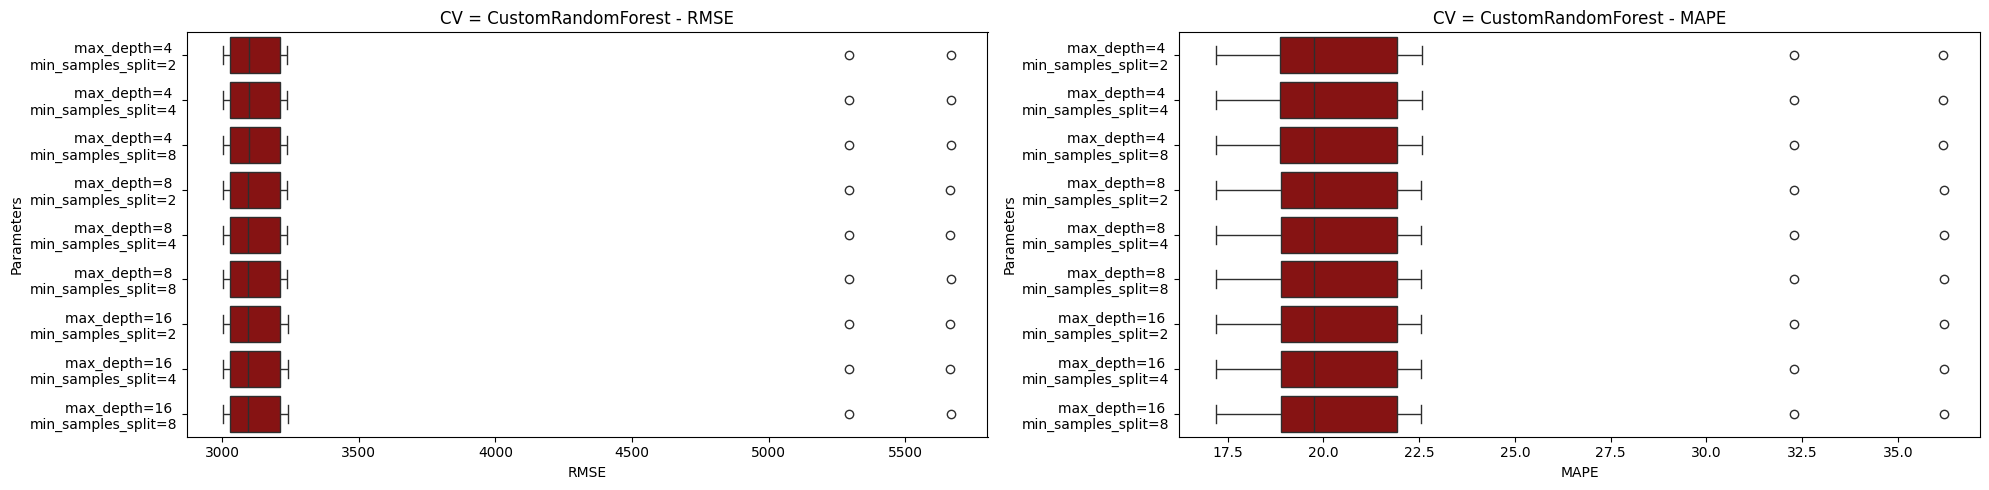

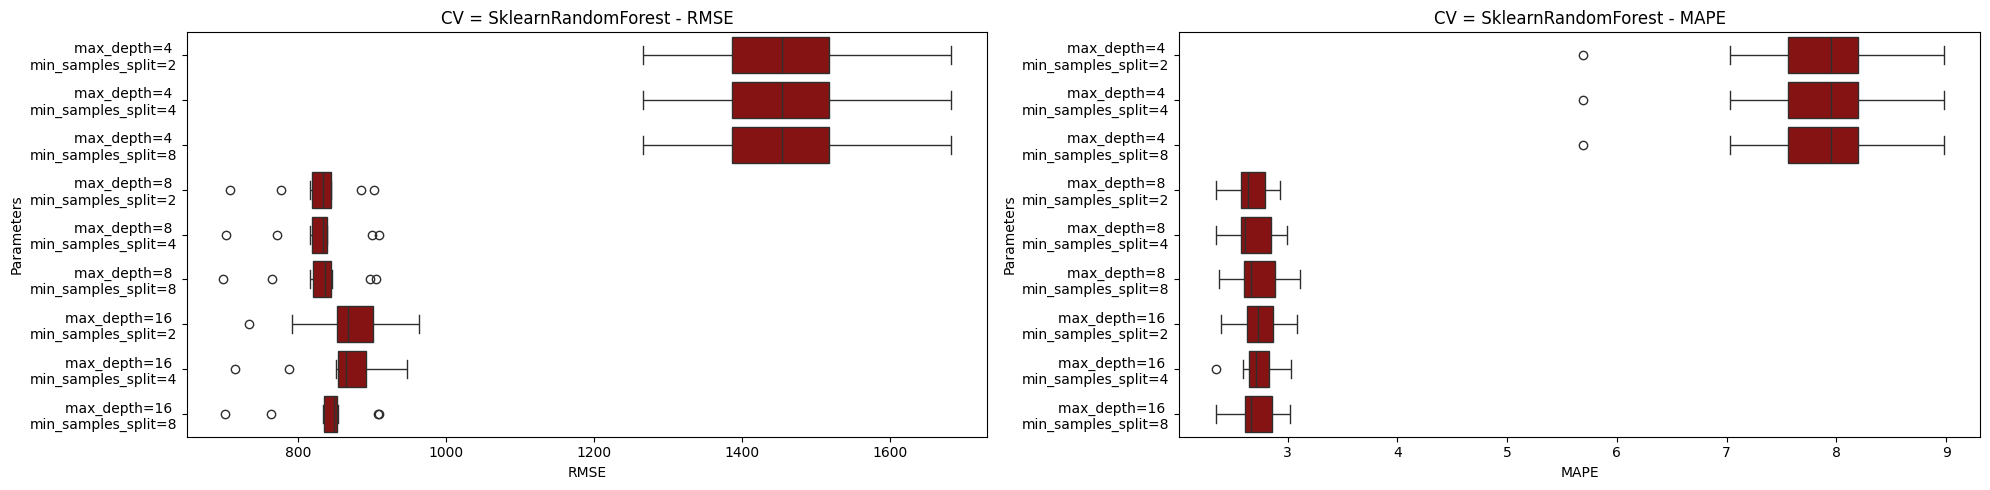

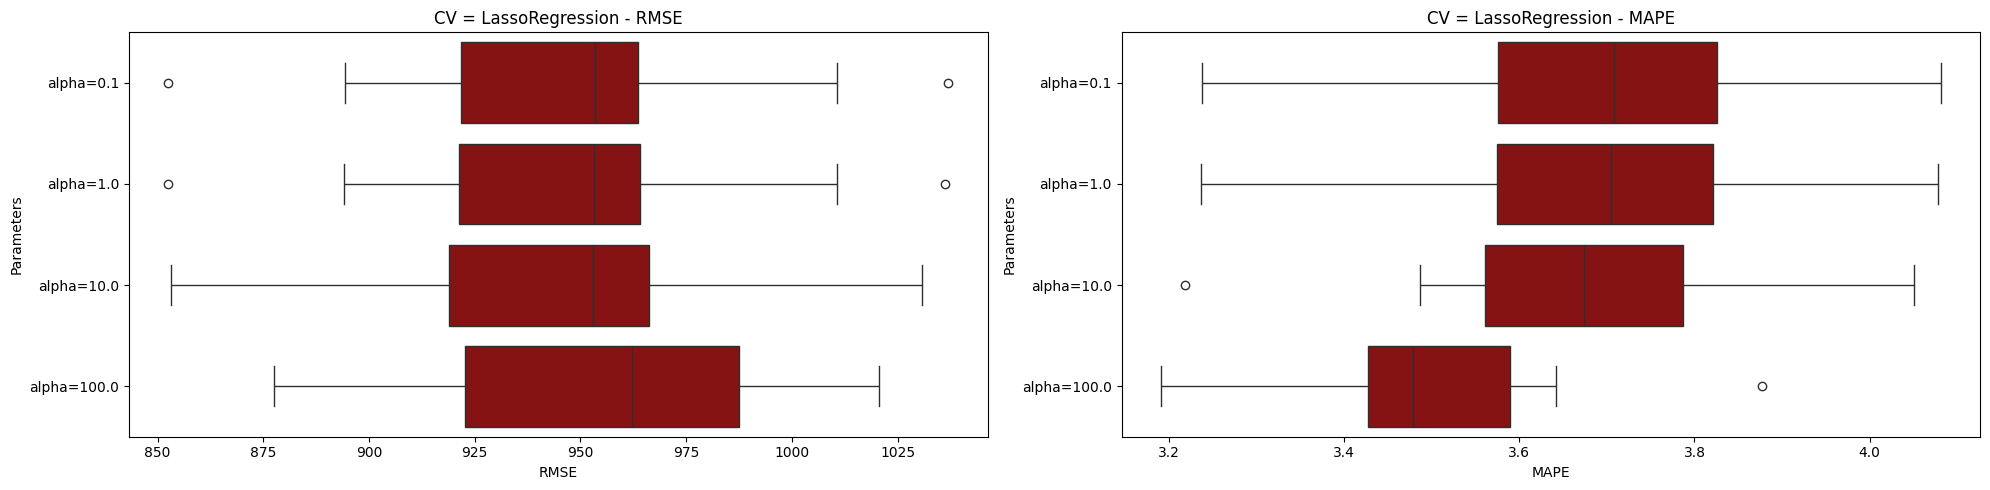

In [9]:
results = []

for name in models_to_run:
    model_data = []

    for version, scores in model_scores.items():
        if name in version:

            _, params_str = version.split("@")

            for metric, score in scores.items():
                part = pd.DataFrame([
                    {
                        "MODEL": name,
                        "PARAMS": params_str,
                        "METRIC": metric,
                        "FOLD": fold,
                        "VALUES": values}
                    for fold, values in enumerate(score)])
                params_dict = part["PARAMS"].apply(
                    lambda s: dict(re.findall(r"([^={},\s]+)=([^={},\s]+)", s))).copy()
                part = part.join(params_dict.apply(pd.Series))
                model_data.append(part)

    detail = pd.concat(model_data)
    
    if "max_depth" in detail.columns:
        detail["max_depth"] = detail["max_depth"].astype(int)

    if "min_samples_split" in detail.columns:
        detail["min_samples_split"] = detail["min_samples_split"].astype(int)

    if "alpha" in detail.columns:
        detail["alpha"] = detail["alpha"].astype(float)

    experiment_cols = ["alpha", "max_depth", "min_samples_split"]
    param_cols = [c for c in experiment_cols if c in detail.columns]
    detail["PARAMETERS"] = detail.apply(
        lambda row: " \n".join(f"{col}={row[col]}" for col in param_cols), axis=1)

    metrics = detail["METRIC"].unique()
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))

    for i, metric in enumerate(metrics):

        detail_metric = detail[detail["METRIC"] == metric]
        sns.boxplot(
            data=detail_metric,
            x="VALUES",
            y="PARAMETERS",
            ax=axes[i],
            color=PLOT_COLOR)
        axes[i].set_ylabel("Parameters")
        axes[i].set_xlabel(metric)
        axes[i].title.set_text(f"CV = {name} - {metric}")
    plt.tight_layout()

    results.append(
        detail.groupby(
            ["MODEL", "PARAMS", "PARAMETERS", "METRIC"])["VALUES"].agg(
                ["mean", "min", "max", "std"]).copy())

In [10]:
result_ranking = pd.concat(results).reset_index()
result_ranking["SCORE"] = result_ranking["mean"] + result_ranking["std"]
best_parameters = {}

for name in models_to_run:
    model_experiments = (result_ranking["MODEL"] == name)
    model_ranking = result_ranking[model_experiments].sort_values(by="SCORE")

    best_row = model_ranking.loc[model_ranking["SCORE"].idxmin()]
    best_parameters[name] = get_parameters(best_row["PARAMS"])

    model_ranking = model_ranking.drop(columns=["PARAMS"], errors="ignore")
    model_ranking["PARAMETERS"] = model_ranking["PARAMETERS"].str.replace("\n", "", regex=False)

    display(
        model_ranking.pivot(
            index=["MODEL", "PARAMETERS"],
            columns="METRIC").sort_values(
                ("SCORE", "RMSE"),
                ascending=True))

mean              \
METRIC                                                     MAPE        RMSE   
MODEL                PARAMETERS                                               
CustomRegressionTree max_depth=4 min_samples_split=2   2.566070  813.030728   
                     max_depth=4 min_samples_split=4   2.566070  813.030728   
                     max_depth=4 min_samples_split=8   2.566070  813.030728   
                     max_depth=8 min_samples_split=8   2.686063  849.918399   
                     max_depth=8 min_samples_split=4   2.695760  857.697288   
                     max_depth=8 min_samples_split=2   2.699423  858.731244   
                     max_depth=16 min_samples_split=8  2.739814  870.575454   
                     max_depth=16 min_samples_split=2  2.793034  888.302701   
                     max_depth=16 min_samples_split=4  2.785385  888.390779   

                                                            min              \
METRIC                                                     MAPE        RMSE   
MODEL                PARAMETERS                                               
CustomRegressionTree max_depth=4 min_samples_split=2   2.237085  666.576743   
                     max_depth=4 min_samples_split=4   2.237085  666.576743   
                     max_depth=4 min_samples_split=8   2.237085  666.576743   
                     max_depth=8 min_samples_split=8   2.359543  715.980326   
                     max_depth=8 min_samples_split=4   2.382044  734.038391   
                     max_depth=8 min_samples_split=2   2.384156  736.840483   
                     max_depth=16 min_samples_split=8  2.390086  728.038295   
                     max_depth=16 min_samples_split=2  2.423666  743.262360   
                     max_depth=16 min_samples_split=4  2.404627  743.065415   

                                                            max               \
METRIC                                                     MAPE         RMSE   
MODEL                PARAMETERS                                                
CustomRegressionTree max_depth=4 min_samples_split=2   2.801338   876.750766   
                     max_depth=4 min_samples_split=4   2.801338   876.750766   
                     max_depth=4 min_samples_split=8   2.801338   876.750766   
                     max_depth=8 min_samples_split=8   3.055969   967.066376   
                     max_depth=8 min_samples_split=4   3.057102   992.200492   
                     max_depth=8 min_samples_split=2   3.057102   992.200492   
                     max_depth=16 min_samples_split=8  3.073541   997.702798   
                     max_depth=16 min_samples_split=2  3.125381  1011.905178   
                     max_depth=16 min_samples_split=4  3.125335  1036.035906   

                                                            std             \
METRIC                                                     MAPE       RMSE   
MODEL                PARAMETERS                                              
CustomRegressionTree max_depth=4 min_samples_split=2   0.159264  58.276346   
                     max_depth=4 min_samples_split=4   0.159264  58.276346   
                     max_depth=4 min_samples_split=8   0.159264  58.276346   
                     max_depth=8 min_samples_split=8   0.210451  71.507999   
                     max_depth=8 min_samples_split=4   0.205679  76.750343   
                     max_depth=8 min_samples_split=2   0.205013  76.305970   
                     max_depth=16 min_samples_split=8  0.200421  73.275344   
                     max_depth=16 min_samples_split=2  0.213002  79.371993   
                     max_depth=16 min_samples_split=4  0.218638  81.849824   

                                                          SCORE              
METRIC                                                     MAPE        RMSE  
MODEL                PARAMETERS                                              
CustomRegressionTree max_dept

mean              \
METRIC                                                      MAPE        RMSE   
MODEL                 PARAMETERS                                               
SklearnRegressionTree max_depth=4 min_samples_split=2   2.566070  813.030728   
                      max_depth=4 min_samples_split=4   2.566070  813.030728   
                      max_depth=4 min_samples_split=8   2.566070  813.030728   
                      max_depth=8 min_samples_split=8   2.684964  848.635535   
                      max_depth=8 min_samples_split=4   2.695016  856.537120   
                      max_depth=8 min_samples_split=2   2.701056  858.741926   
                      max_depth=16 min_samples_split=8  2.738923  868.825498   
                      max_depth=16 min_samples_split=2  2.790526  884.202989   
                      max_depth=16 min_samples_split=4  2.789650  888.424109   

                                                             min              \
METRIC                                                      MAPE        RMSE   
MODEL                 PARAMETERS                                               
SklearnRegressionTree max_depth=4 min_samples_split=2   2.237085  666.576743   
                      max_depth=4 min_samples_split=4   2.237085  666.576743   
                      max_depth=4 min_samples_split=8   2.237085  666.576743   
                      max_depth=8 min_samples_split=8   2.359543  715.980326   
                      max_depth=8 min_samples_split=4   2.382044  734.038391   
                      max_depth=8 min_samples_split=2   2.384156  736.840483   
                      max_depth=16 min_samples_split=8  2.390086  728.038295   
                      max_depth=16 min_samples_split=2  2.423666  743.262360   
                      max_depth=16 min_samples_split=4  2.404627  743.065415   

                                                             max               \
METRIC                                                      MAPE         RMSE   
MODEL                 PARAMETERS                                                
SklearnRegressionTree max_depth=4 min_samples_split=2   2.801338   876.750766   
                      max_depth=4 min_samples_split=4   2.801338   876.750766   
                      max_depth=4 min_samples_split=8   2.801338   876.750766   
                      max_depth=8 min_samples_split=8   3.055969   967.066376   
                      max_depth=8 min_samples_split=4   3.057102   992.200492   
                      max_depth=8 min_samples_split=2   3.057102   992.200492   
                      max_depth=16 min_samples_split=8  3.073541   997.702798   
                      max_depth=16 min_samples_split=2  3.125381  1011.936801   
                      max_depth=16 min_samples_split=4  3.138015  1036.066792   

                                                             std             \
METRIC                                                      MAPE       RMSE   
MODEL                 PARAMETERS                                              
SklearnRegressionTree max_depth=4 min_samples_split=2   0.159264  58.276346   
                      max_depth=4 min_samples_split=4   0.159264  58.276346   
                      max_depth=4 min_samples_split=8   0.159264  58.276346   
                      max_depth=8 min_samples_split=8   0.211307  72.821183   
                      max_depth=8 min_samples_split=4   0.206495  78.339227   
                      max_depth=8 min_samples_split=2   0.204609  76.302970   
                      max_depth=16 min_samples_split=8  0.201352  74.459861   
                      max_depth=16 min_samples_split=2  0.217319  83.577340   
                      max_depth=16 min_samples_split=4  0.220756  81.852881   

                                                           SCORE              
METRIC                                                      MAPE        RMSE  
MODEL                 PARAMETERS                          

mean               \
METRIC                                                    MAPE         RMSE   
MODEL              PARAMETERS                                                 
CustomRandomForest max_depth=16 min_samples_split=2  22.421617  3561.625451   
                   max_depth=16 min_samples_split=4  22.421617  3561.625451   
                   max_depth=8 min_samples_split=2   22.421574  3561.643717   
                   max_depth=8 min_samples_split=4   22.421574  3561.643717   
                   max_depth=16 min_samples_split=8  22.421545  3561.618937   
                   max_depth=8 min_samples_split=8   22.421502  3561.637204   
                   max_depth=4 min_samples_split=8   22.421146  3561.379122   
                   max_depth=4 min_samples_split=2   22.421146  3561.379122   
                   max_depth=4 min_samples_split=4   22.421146  3561.379122   

                                                           min               \
METRIC                                                    MAPE         RMSE   
MODEL              PARAMETERS                                                 
CustomRandomForest max_depth=16 min_samples_split=2  17.188325  3003.872699   
                   max_depth=16 min_samples_split=4  17.188325  3003.872699   
                   max_depth=8 min_samples_split=2   17.188376  3003.971535   
                   max_depth=8 min_samples_split=4   17.188376  3003.971535   
                   max_depth=16 min_samples_split=8  17.188285  3003.872699   
                   max_depth=8 min_samples_split=8   17.188336  3003.971535   
                   max_depth=4 min_samples_split=8   17.195847  3004.175717   
                   max_depth=4 min_samples_split=2   17.195847  3004.175717   
                   max_depth=4 min_samples_split=4   17.195847  3004.175717   

                                                           max               \
METRIC                                                    MAPE         RMSE   
MODEL              PARAMETERS                                                 
CustomRandomForest max_depth=16 min_samples_split=2  36.196450  5666.000642   
                   max_depth=16 min_samples_split=4  36.196450  5666.000642   
                   max_depth=8 min_samples_split=2   36.196455  5665.987871   
                   max_depth=8 min_samples_split=4   36.196455  5665.987871   
                   max_depth=16 min_samples_split=8  36.196662  5666.153499   
                   max_depth=8 min_samples_split=8   36.196667  5666.140729   
                   max_depth=4 min_samples_split=8   36.190851  5668.264171   
                   max_depth=4 min_samples_split=2   36.190851  5668.264171   
                   max_depth=4 min_samples_split=4   36.190851  5668.264171   

                                                          std               \
METRIC                                                   MAPE         RMSE   
MODEL              PARAMETERS                                                
CustomRandomForest max_depth=16 min_samples_split=2  6.444137  1017.032552   
                   max_depth=16 min_samples_split=4  6.444137  1017.032552   
                   max_depth=8 min_samples_split=2   6.444150  1017.017736   
                   max_depth=8 min_samples_split=4   6.444150  1017.017736   
                   max_depth=16 min_samples_split=8  6.444263  1017.090172   
                   max_depth=8 min_samples_split=8   6.444275  1017.075358   
                   max_depth=4 min_samples_split=8   6.444445  1018.507824   
                   max_depth=4 min_samples_split=2   6.444445  1018.507824   
                   max_depth=4 min_samples_split=4   6.444445  1018.507824   

                                                         SCORE               
METRIC                                                    MAPE         RMSE  
MODEL              PARAMETERS                                                
CustomRandomForest max_depth=16 min_samp

mean               \
METRIC                                                    MAPE         RMSE   
MODEL               PARAMETERS                                                
SklearnRandomForest max_depth=8 min_samples_split=2   2.670699   826.863835   
                    max_depth=8 min_samples_split=4   2.682938   827.045266   
                    max_depth=8 min_samples_split=8   2.729785   826.989902   
                    max_depth=16 min_samples_split=8  2.701084   835.448399   
                    max_depth=16 min_samples_split=4  2.728312   860.314363   
                    max_depth=16 min_samples_split=2  2.751456   866.799993   
                    max_depth=4 min_samples_split=8   7.806369  1456.551412   
                    max_depth=4 min_samples_split=2   7.806369  1456.551412   
                    max_depth=4 min_samples_split=4   7.806369  1456.551412   

                                                           min               \
METRIC                                                    MAPE         RMSE   
MODEL               PARAMETERS                                                
SklearnRandomForest max_depth=8 min_samples_split=2   2.349423   707.051355   
                    max_depth=8 min_samples_split=4   2.351760   701.722730   
                    max_depth=8 min_samples_split=8   2.371815   698.396739   
                    max_depth=16 min_samples_split=8  2.345503   701.521164   
                    max_depth=16 min_samples_split=4  2.351415   714.935903   
                    max_depth=16 min_samples_split=2  2.395125   733.749256   
                    max_depth=4 min_samples_split=8   5.691264  1265.932555   
                    max_depth=4 min_samples_split=2   5.691264  1265.932555   
                    max_depth=4 min_samples_split=4   5.691264  1265.932555   

                                                           max               \
METRIC                                                    MAPE         RMSE   
MODEL               PARAMETERS                                                
SklearnRandomForest max_depth=8 min_samples_split=2   2.928344   901.945326   
                    max_depth=8 min_samples_split=4   2.992652   908.925063   
                    max_depth=8 min_samples_split=8   3.112999   904.552928   
                    max_depth=16 min_samples_split=8  3.021541   908.771343   
                    max_depth=16 min_samples_split=4  3.027308   946.829136   
                    max_depth=16 min_samples_split=2  3.085471   963.389604   
                    max_depth=4 min_samples_split=8   8.976909  1682.882830   
                    max_depth=4 min_samples_split=2   8.976909  1682.882830   
                    max_depth=4 min_samples_split=4   8.976909  1682.882830   

                                                           std              \
METRIC                                                    MAPE        RMSE   
MODEL               PARAMETERS                                               
SklearnRandomForest max_depth=8 min_samples_split=2   0.181752   54.397267   
                    max_depth=8 min_samples_split=4   0.207140   59.007796   
                    max_depth=8 min_samples_split=8   0.218822   59.766610   
                    max_depth=16 min_samples_split=8  0.203382   62.096072   
                    max_depth=16 min_samples_split=4  0.192464   68.008975   
                    max_depth=16 min_samples_split=2  0.203613   67.672213   
                    max_depth=4 min_samples_split=8   0.940465  117.187744   
                    max_depth=4 min_samples_split=2   0.940465  117.187744   
                    max_depth=4 min_samples_split=4   0.940465  117.187744   

                                                         SCORE               
METRIC                                                    MAPE         RMSE  
MODEL               PARAMETERS                                               
SklearnRandomForest max_depth=8 min_samp

mean                   min              \
METRIC                           MAPE        RMSE      MAPE        RMSE   
MODEL           PARAMETERS                                                
LassoRegression alpha=10.0   3.672839  947.679173  3.217892  853.178413   
                alpha=1.0    3.703729  948.295767  3.236002  852.513150   
                alpha=0.1    3.707397  948.472433  3.237496  852.558585   
                alpha=100.0  3.496466  957.440732  3.190519  877.431888   

                                  max                    std             \
METRIC                           MAPE         RMSE      MAPE       RMSE   
MODEL           PARAMETERS                                                
LassoRegression alpha=10.0   4.051055  1030.722234  0.234345  52.517246   
                alpha=1.0    4.077862  1036.300201  0.242269  53.161885   
                alpha=0.1    4.081494  1037.049990  0.243574  53.209541   
                alpha=100.0  3.877052  1020.643180  0.188003  45.588152   

                                SCORE               
METRIC                           MAPE         RMSE  
MODEL           PARAMETERS                          
LassoRegression alpha=10.0   3.907184  1000.196418  
                alpha=1.0    3.945999  1001.457652  
                alpha=0.1    3.950971  1001.681974  
                alpha=100.0  3.684469  1003.028884

### Holdout Performance

In [11]:
features = [c for c in df_trn if c != LABEL]
numeric_features = df_trn[features].select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in features if c not in numeric_features]

X_trn_raw = df_trn[features]
X_tst_raw = df_tst[features]

y_trn = df_trn[LABEL].values
y_tst = df_tst[LABEL].values

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features),
        (
            "num",
            StandardScaler(),
            numeric_features)])

X_trn = preprocessor.fit_transform(X_trn_raw)
X_tst = preprocessor.transform(X_tst_raw)

test_scores = {}
for name, params in best_parameters.items():
    
    regressor = models_to_run[name][0]
    model = regressor(**params)
    model.fit(X_trn, y_trn)
    prediction = model.predict(X_tst)
    test_scores[name] = get_scores(y_tst, prediction)
    print(name, test_scores[name])

CustomRegressionTree {'RMSE': np.float64(806.2210908495672), 'MAPE': np.float64(2.5753240394450128)}
SklearnRegressionTree {'RMSE': np.float64(806.2210908495672), 'MAPE': np.float64(2.5753240394450128)}
CustomRandomForest {'RMSE': np.float64(2605.1348605287635), 'MAPE': np.float64(15.723041479730496)}
SklearnRandomForest {'RMSE': np.float64(835.1559587325247), 'MAPE': np.float64(2.6802910049163375)}
LassoRegression {'RMSE': np.float64(952.487043003008), 'MAPE': np.float64(3.391258989193741)}


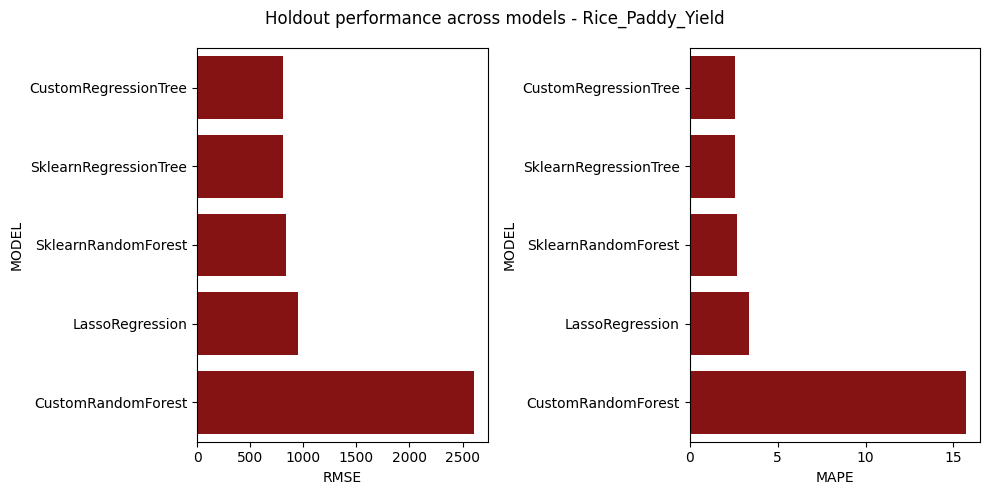

In [12]:
test_performance = pd.DataFrame([
    {"MODEL": name, "RMSE": test_scores[name]["RMSE"], "MAPE": test_scores[name]["MAPE"]}
    for name in test_scores
])
test_performance = test_performance.sort_values(by="RMSE")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.barplot(data=test_performance, y="MODEL", x="RMSE", ax=axes[0], color=PLOT_COLOR)
sns.barplot(data=test_performance, y="MODEL", x="MAPE", ax=axes[1], color=PLOT_COLOR)
plt.suptitle(f"Holdout performance across models - {DATASET}")
plt.tight_layout()

by [Manuel Velarde](mailto:manuel@velarde.me)